In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

/Users/omarquinn/.matplotlib is not a writable directory
Matplotlib created a temporary cache directory at /var/folders/ym/rbj3xt1s2z99f7dbk593w20h0000gn/T/matplotlib-3_czr118 because there was an issue with the default path (/Users/omarquinn/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Matplotlib is building the font cache; this may take a moment.


In [2]:
df=pd.read_csv("Budapest_Hungria.csv")

In [3]:
#Primer segmentacion con variables “review_scores_accuracy” y “number_of_reviews”

X = df[['review_scores_accuracy', 'number_of_reviews']].copy()
X

,review_scores_accuracy,number_of_reviews
0,4.69,128
1,4.83,55
2,4.49,268
3,4.57,265
4,4.61,259
...,...,...
12308,NaN,0
12309,NaN,0
12310,NaN,0
12311,NaN,0


In [4]:
X=X.dropna()

In [5]:
scaler1 = StandardScaler()
X_scaled = scaler1.fit_transform(X)

In [6]:
kmeans1 = KMeans(n_clusters=3 , random_state=42)
kmeans1

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [7]:
etiquetas1 = kmeans1.fit_predict(X_scaled)
etiquetas1

array([1, 0, 1, ..., 0, 0, 0], shape=(11239,), dtype=int32)

In [8]:
centroides1 = kmeans1.cluster_centers_
centroides1

array([[-0.10158653, -0.51920567],
       [ 0.20013688,  0.59740463],
       [ 0.27770459,  2.69964396]])

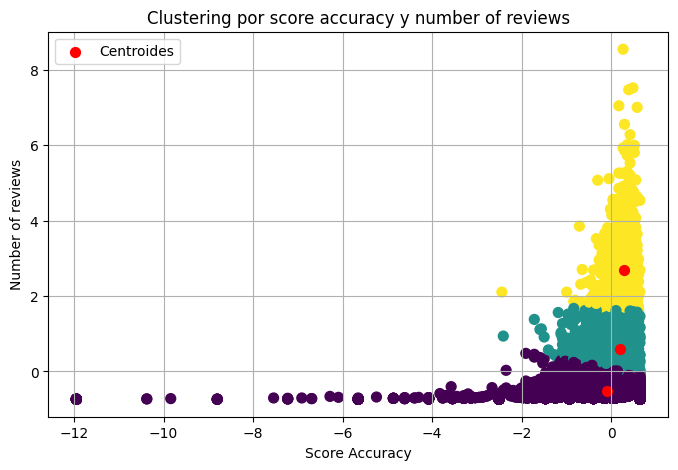

In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=etiquetas1, cmap='viridis', s=50)
plt.scatter(centroides1[:, 0], centroides1[:, 1], c='red', marker='.', s=200, label='Centroides')

plt.title("Clustering por score accuracy y number of reviews")
plt.xlabel("Score Accuracy")
plt.ylabel("Number of reviews")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
df['price'] = pd.to_numeric(
    df['price'].astype(str).str.replace(r'[^\d\.-]', '', regex=True),
    errors='coerce'
)

In [11]:
#Segmentacion ejercicio 2

X1 = df[['host_listings_count', 'accommodates','beds', 'price']].copy()
X1

,host_listings_count,accommodates,beds,price
0,3,3,2.0,27895.0
1,3,3,3.0,27801.0
2,34,3,2.0,22016.0
3,34,3,2.0,22581.0
4,34,3,2.0,23147.0
...,...,...,...,...
12308,8,2,1.0,20571.0
12309,8,2,1.0,20057.0
12310,1,4,2.0,29440.0
12311,8,2,1.0,20057.0


In [12]:
X1=X1.dropna()

In [13]:
scaler2 = StandardScaler()
X_scaled1 = scaler2.fit_transform(X1)

In [14]:
kmeans2 = KMeans(n_clusters=2 , random_state=42)
kmeans2

,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [15]:
etiquetas2 = kmeans2.fit_predict(X_scaled1)
etiquetas2

array([1, 1, 1, ..., 1, 1, 1], shape=(11655,), dtype=int32)

In [16]:
centorides2 = kmeans2.cluster_centers_
centorides2

array([[ 0.23009001,  2.1627659 ,  1.91165378,  0.38516869],
       [-0.02672852, -0.25123875, -0.22206819, -0.04474331]])

In [17]:
pca1 = PCA(n_components=2)
x2_pca= pca1.fit_transform(X_scaled1)
centroides2_pca = pca1.fit_transform(centorides2)

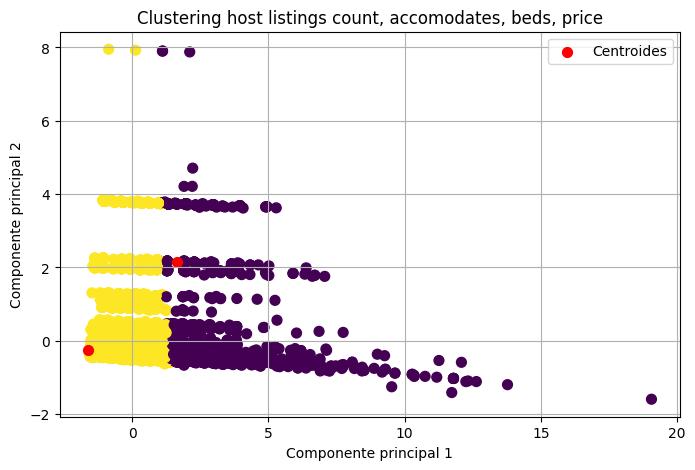

In [18]:
plt.figure(figsize=(8, 5))
plt.scatter(x2_pca[:, 0], x2_pca[:, 1],c=etiquetas2, cmap='viridis', s=50)
plt.scatter(centroides2_pca[:, 0], centorides2[:, 1], c='red', marker= '.', s=200, label = 'Centroides')

plt.title('Clustering host listings count, accomodates, beds, price')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
#Clustering 3 “price”, “review_scores_value”, “review_scores_location” y “price”
X3= df[['price', 'review_scores_value', 'review_scores_location']].copy()
X3

,price,review_scores_value,review_scores_location
0,27895.0,4.69,4.87
1,27801.0,4.83,4.98
2,22016.0,4.63,4.87
3,22581.0,4.67,4.87
4,23147.0,4.67,4.91
...,...,...,...
12308,20571.0,NaN,NaN
12309,20057.0,NaN,NaN
12310,29440.0,NaN,NaN
12311,20057.0,NaN,NaN


In [20]:
X3 = X3.dropna()

In [21]:
scaler3 = StandardScaler()
X_scaled3 = scaler3.fit_transform(X3)

In [22]:
kmeans3 = KMeans(n_clusters=5, random_state=42)
kmeans3

,n_clusters,5
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [23]:
etiquetas3 = kmeans3.fit_predict(X_scaled3)
etiquetas3

array([1, 1, 1, ..., 1, 1, 1], shape=(10664,), dtype=int32)

In [24]:
centroides3 = kmeans3.cluster_centers_
centroides3

array([[-1.57389101e-02, -3.53200184e+00, -2.67119356e+00],
       [-1.10999052e-02,  3.30770647e-01,  3.21317008e-01],
       [ 5.71407206e+01, -2.60222948e+00,  5.52676733e-02],
       [-3.26069374e-02, -5.42486991e-01, -5.93654736e-01],
       [ 5.81988999e-02, -9.31719851e+00, -1.08672230e+01]])

In [25]:
pca3 = PCA(n_components=2)
X3_pca = pca3.fit_transform(X_scaled3)
centroides3_pca = pca3.fit_transform(centroides3)

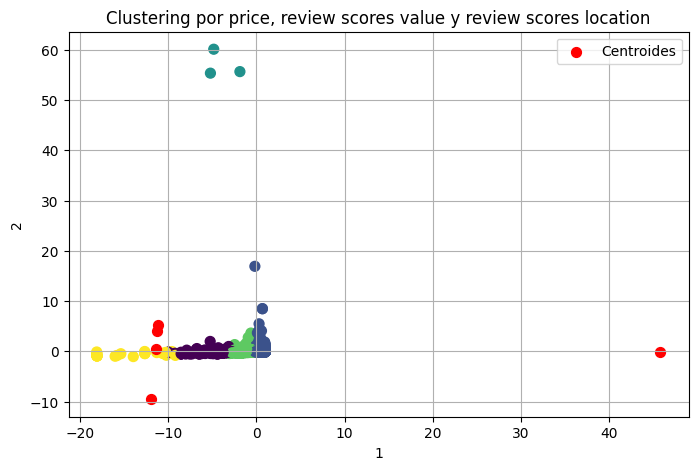

In [26]:
plt.figure(figsize=(8 ,5))
plt.scatter(X3_pca[:, 0], X3_pca[:, 1], c=etiquetas3, cmap='viridis', s=50)
plt.scatter(centroides3_pca[:, 0 ], centroides3_pca[:, 1], c='red', marker='.', s=200, label='Centroides')

plt.title("Clustering por price, review scores value y review scores location")
plt.xlabel("1")
plt.ylabel("2")
plt.legend()
plt.grid(True)
plt.show()

In [27]:
#Clustering 4

X4=df[['host_listings_count', 'accommodates', 'beds',  'availability_30']]
X4

,host_listings_count,accommodates,beds,availability_30
0,3,3,2.0,17
1,3,3,3.0,8
2,34,3,2.0,4
3,34,3,2.0,2
4,34,3,2.0,5
...,...,...,...,...
12308,8,2,1.0,30
12309,8,2,1.0,30
12310,1,4,2.0,29
12311,8,2,1.0,30


In [28]:
cols = ['host_listings_count','accommodates','beds','availability_30']
X4 = df[cols].copy()
X4 = X4.apply(pd.to_numeric, errors='coerce') 

In [29]:
X4 = X4.fillna(0)

In [30]:
scaler4 = StandardScaler()
X_scaled4 = scaler4.fit_transform(X4)


In [31]:
kmeans4 = KMeans(n_clusters=5, random_state=42)
kmeans4

,n_clusters,5
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [32]:
etiquetas4 = kmeans4.fit_predict(X_scaled4)
etiquetas4

array([4, 0, 0, ..., 4, 4, 4], shape=(12313,), dtype=int32)

In [33]:
centroides4 = kmeans4.cluster_centers_
centroides4

array([[-0.33299678, -0.41485118, -0.35357242, -0.79792181],
       [ 0.15346664,  3.79965509,  4.23046491,  0.29249932],
       [-0.22726084,  1.15577161,  0.82429687, -0.07391577],
       [ 2.74244839, -0.10578885, -0.12401279, -0.38681717],
       [-0.24173701, -0.36210122, -0.27798869,  0.99357938]])

In [34]:
pca4 = PCA(n_components=2)
X4_pca = pca4.fit_transform(X_scaled4)
centroides4_pca = pca4.fit_transform(centroides4)

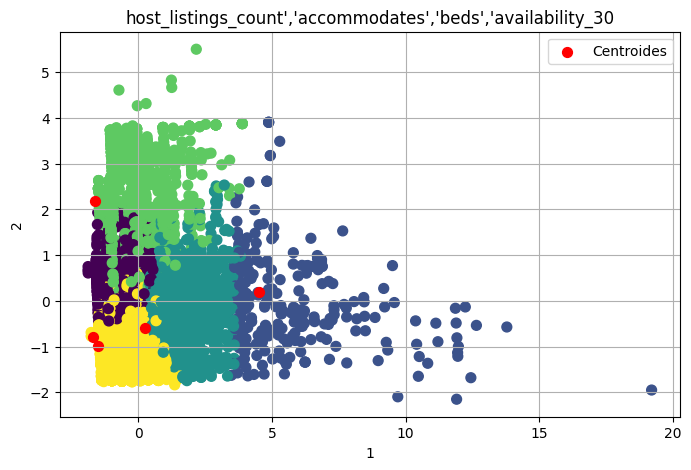

In [35]:
plt.figure(figsize=(8 ,5))
plt.scatter(X4_pca[:, 0], X4_pca[:, 1], c=etiquetas4, cmap='viridis', s=50)
plt.scatter(centroides4_pca[:, 0 ], centroides4_pca[:, 1], c='red', marker='.', s=200, label='Centroides')

plt.title("host_listings_count','accommodates','beds','availability_30")
plt.xlabel("1")
plt.ylabel("2")
plt.legend()
plt.grid(True)
plt.show()

In [36]:
#Cluster 5

In [55]:
df['host_acceptance_rate'] = (
    df['host_acceptance_rate']
    .astype(str)
    .str.replace('%', '', regex=False)
    .replace(['nan', 'None', '', 'NaN'], '0')
    .astype(float)
)

In [56]:
X5=df[['reviews_per_month', 'calculated_host_listings_count', 'review_scores_cleanliness',  'review_scores_rating','host_acceptance_rate']]
X5

,reviews_per_month,calculated_host_listings_count,review_scores_cleanliness,review_scores_rating,host_acceptance_rate
0,0.67,3,4.86,4.80,98.0
1,0.31,3,5.00,4.79,98.0
2,1.44,34,4.46,4.48,100.0
3,1.46,34,4.55,4.56,100.0
4,1.46,34,4.43,4.54,100.0
...,...,...,...,...,...
12308,NaN,8,NaN,NaN,58.0
12309,NaN,8,NaN,NaN,58.0
12310,NaN,1,NaN,NaN,0.0
12311,NaN,8,NaN,NaN,58.0


In [57]:
X5 = X5.fillna(0)

In [58]:
scaler5 = StandardScaler()
X_scaled5 = scaler5.fit_transform(X5)

In [59]:
kmeans5 = KMeans(n_clusters=5, random_state=42)
kmeans5

,n_clusters,5
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [60]:
etiquetas5 = kmeans5.fit_predict(X_scaled5)
etiquetas5

array([3, 3, 3, ..., 1, 1, 1], shape=(12313,), dtype=int32)

In [61]:
centroides5 = kmeans5.cluster_centers_
centroides5

array([[ 1.2545749 , -0.34715956,  0.36381589,  0.36475464,  0.33941078],
       [-1.10730735,  0.04805428, -3.08840072, -3.10115624, -0.5791261 ],
       [-0.44018549, -0.37989887,  0.31337247,  0.31096532, -3.19991802],
       [-0.47957507, -0.27413741,  0.30094238,  0.29826245,  0.244321  ],
       [ 0.23072144,  2.74002456,  0.15145766,  0.17756735,  0.35809627]])

In [62]:
pca5 = PCA(n_components=2)
X5_pca = pca5.fit_transform(X_scaled5)
centroides5_pca = pca5.fit_transform(centroides5)

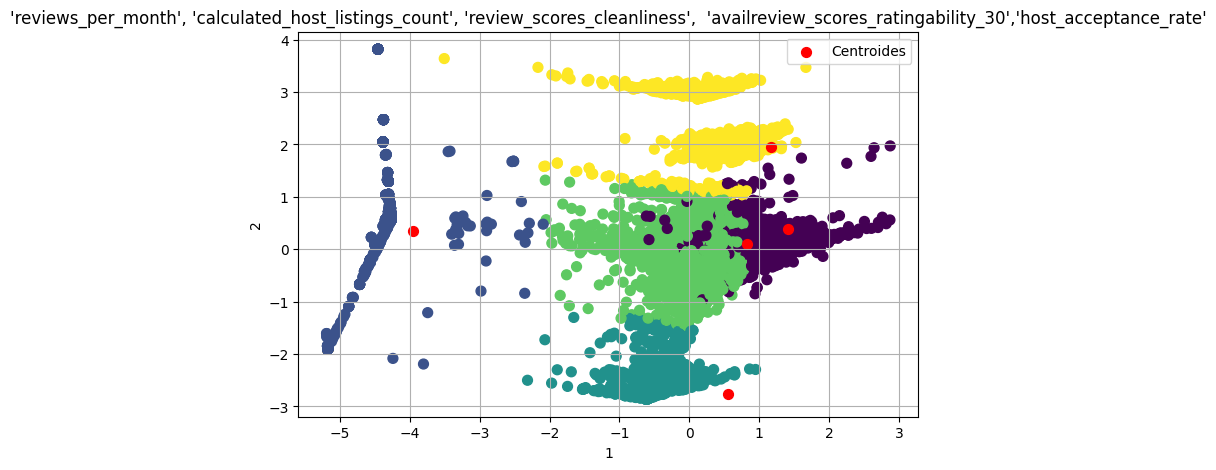

In [63]:
plt.figure(figsize=(8 ,5))
plt.scatter(X5_pca[:, 0], X5_pca[:, 1], c=etiquetas5, cmap='viridis', s=50)
plt.scatter(centroides5_pca[:, 0 ], centroides5_pca[:, 1], c='red', marker='.', s=200, label='Centroides')

plt.title("'reviews_per_month', 'calculated_host_listings_count', 'review_scores_cleanliness',  'availreview_scores_ratingability_30','host_acceptance_rate'")
plt.xlabel("1")
plt.ylabel("2")
plt.legend()
plt.grid(True)
plt.show()